# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

---



- Nama: Irfan Maulana
- Email: irfanmau1605@gmail.com
- Id Dicoding: melonpan730

## Persiapan

### Menyiapkan library yang dibutuhkan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')



### Menyiapkan data yang akan diguankan

## Data Understanding

Dataset terdiri dari 1470 karyawan dengan 35 fitur yang mencakup demografi, kondisi kerja, dan kepuasan kerja.

In [ ]:
# Load dataset
df = pd.read_csv('https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/main/employee/employee_data.csv')
print('Dataset Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Dataset Shape: (1470, 35)

First 5 rows:


,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel

In [ ]:
df.describe(include='all')

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1058.000000,1470,1470.000000,1470,1470.000000,1470.000000,1470,1470.0,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
unique,NaN,NaN,NaN,3,NaN,3,NaN,NaN,6,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,Travel_Rarely,NaN,Research & Development,NaN,NaN,Life Sciences,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,1043,NaN,961,NaN,NaN,606,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,735.500000,36.923810,0.169187,NaN,802.485714,NaN,9.192517,2.912925,NaN,1.0,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,424.496761,9.135373,0.375094,NaN,403.509100,NaN,8.106864,1.024165,NaN,0.0,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,1.000000,18.000000,0.000000,NaN,102.000000,NaN,1.000000,1.000000,NaN,1.0,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,368.250000,30.000000,0.000000,NaN,465.000000,NaN,2.000000,2.000000,NaN,1.0,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,735.500000,36.000000,0.000000,NaN,802.000000,NaN,7.000000,3.000000,NaN,1.0,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1102.750000,43.000000,0.000000,NaN,1157.000000,NaN,14.000000,4.000000,NaN,1.0,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000


In [ ]:
# Cek missing values
print('Missing Values per Column:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('\nAttrition Distribution (sebelum drop NA):')
print(df['Attrition'].value_counts(dropna=False))

Missing Values per Column:
Attrition    412
dtype: int64

Attrition Distribution (sebelum drop NA):
Attrition
0.0    879
NaN    412
1.0    179
Name: count, dtype: int64


## Data Preparation / Preprocessing

In [ ]:
# Drop kolom yang tidak relevan
df = df.drop(columns=['EmployeeId', 'Over18', 'StandardHours', 'EmployeeCount'])
print('Kolom setelah drop:', df.shape)

# Drop baris dengan Attrition kosong (tidak bisa digunakan untuk analisis)
df = df.dropna(subset=['Attrition'])
print('Shape setelah drop Attrition NA:', df.shape)

# Convert Attrition ke integer
df['Attrition'] = df['Attrition'].astype(int)

print('\nAttrition Distribution (setelah cleaning):')
print(df['Attrition'].value_counts())
print(f'\nAttrition Rate: {df["Attrition"].mean()*100:.2f}%')

Kolom setelah drop: (1470, 31)
Shape setelah drop Attrition NA: (1058, 31)

Attrition Distribution (setelah cleaning):
Attrition
0    879
1    179
Name: count, dtype: int64

Attrition Rate: 16.92%


In [ ]:
# Encoding categorical columns
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Categorical columns:', cat_cols)

df_encoded = df.copy()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print('\nEncoding selesai. Shape:', df_encoded.shape)
df_encoded.head()

Categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Encoding selesai. Shape: (1058, 31)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1,37,1,2,1141,1,11,2,3,1,0,...,3,1,0,15,2,1,1,0,0,0
2,51,1,2,1323,1,4,4,1,1,1,...,3,3,3,18,2,4,10,0,2,7
3,42,0,1,555,2,26,3,2,3,0,...,3,4,1,23,2,4,20,4,4,8
6,40,0,2,1124,2,1,2,3,2,1,...,4,3,3,6,2,2,4,3,0,2
7,55,1,2,725,1,2,3,3,4,1,...,3,4,1,24,2,3,5,2,1,4


## Exploratory Data Analysis (EDA)

In [ ]:
# Setup style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Label Attrition untuk visualisasi
df['AttritionLabel'] = df['Attrition'].map({0: 'No', 1: 'Yes'})

<Figure size 800x500 with 0 Axes>

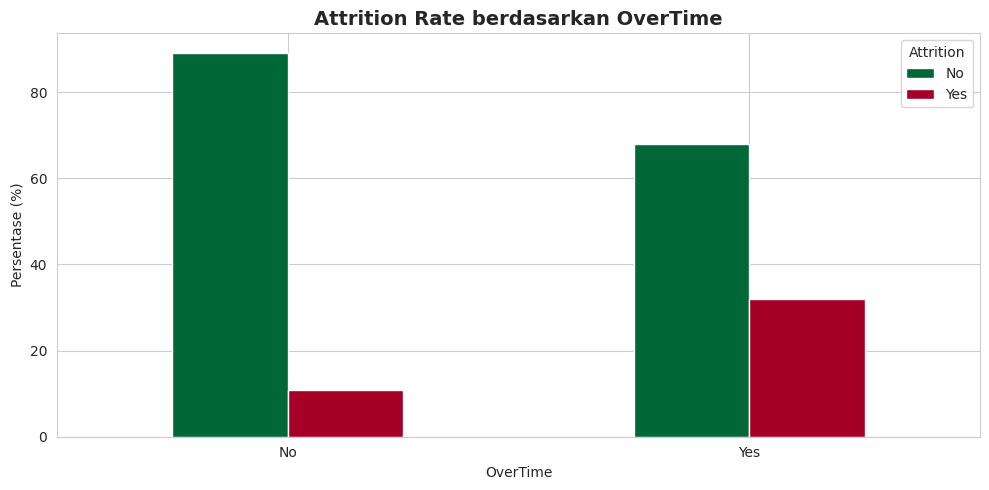

Insight: Karyawan yang sering melakukan overtime memiliki tingkat attrition yang lebih tinggi dibandingkan yang tidak.


In [ ]:
# OverTime vs Attrition
plt.figure(figsize=(8, 5))
overtime_attr = df.groupby(['OverTime', 'AttritionLabel']).size().unstack(fill_value=0)
overtime_attr_pct = overtime_attr.div(overtime_attr.sum(axis=1), axis=0) * 100
overtime_attr_pct.plot(kind='bar', colormap='RdYlGn_r', edgecolor='white')
plt.title('Attrition Rate berdasarkan OverTime', fontsize=14, fontweight='bold')
plt.xlabel('OverTime')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=0)
plt.legend(title='Attrition')
plt.tight_layout()
plt.savefig('plot_overtime_attrition.png', dpi=150)
plt.show()

print('Insight: Karyawan yang sering melakukan overtime memiliki tingkat attrition yang lebih tinggi dibandingkan yang tidak.')

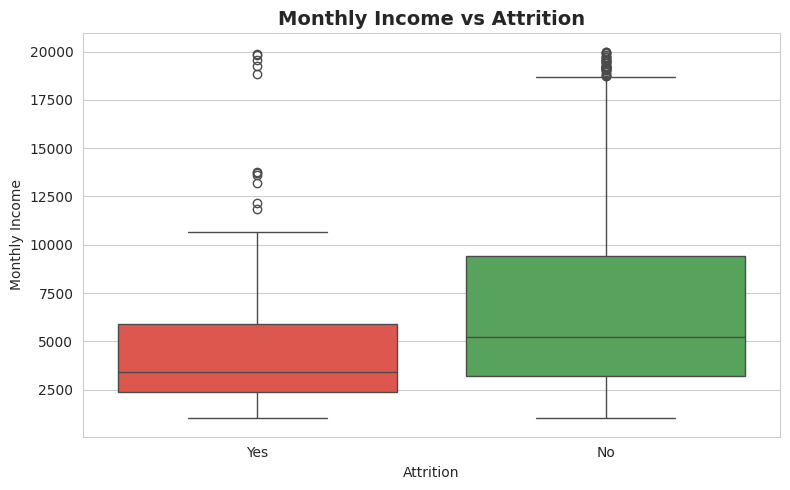

Insight: Karyawan dengan pendapatan lebih rendah cenderung lebih sering keluar dari perusahaan.


In [ ]:
# MonthlyIncome vs Attrition
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='AttritionLabel', y='MonthlyIncome',
            palette={'No': '#4CAF50', 'Yes': '#F44336'})
plt.title('Monthly Income vs Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income')
plt.tight_layout()
plt.savefig('plot_income_attrition.png', dpi=150)
plt.show()

print('Insight: Karyawan dengan pendapatan lebih rendah cenderung lebih sering keluar dari perusahaan.')

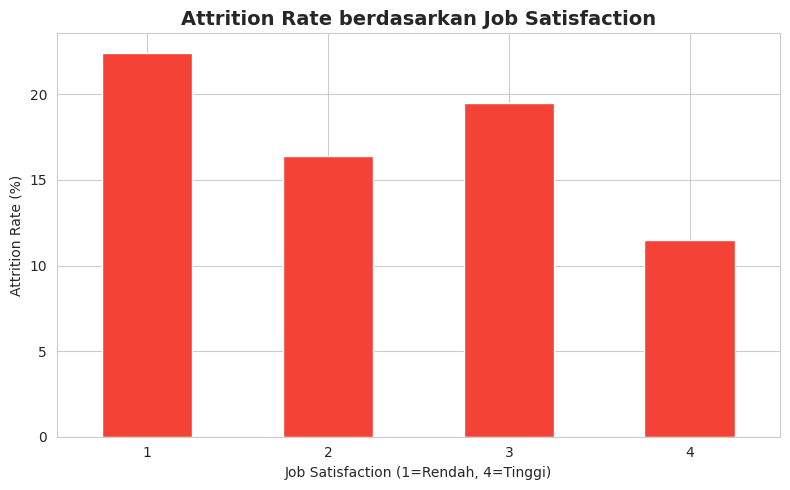

Insight: Karyawan dengan tingkat kepuasan kerja rendah memiliki kemungkinan resign lebih tinggi.


In [ ]:
# JobSatisfaction vs Attrition
plt.figure(figsize=(8, 5))
jobsat_attr = df.groupby(['JobSatisfaction', 'AttritionLabel']).size().unstack(fill_value=0)
jobsat_attr_pct = jobsat_attr.div(jobsat_attr.sum(axis=1), axis=0) * 100
jobsat_attr_pct['Yes'].plot(kind='bar', color='#F44336', edgecolor='white')
plt.title('Attrition Rate berdasarkan Job Satisfaction', fontsize=14, fontweight='bold')
plt.xlabel('Job Satisfaction (1=Rendah, 4=Tinggi)')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('plot_jobsat_attrition.png', dpi=150)
plt.show()

print('Insight: Karyawan dengan tingkat kepuasan kerja rendah memiliki kemungkinan resign lebih tinggi.')

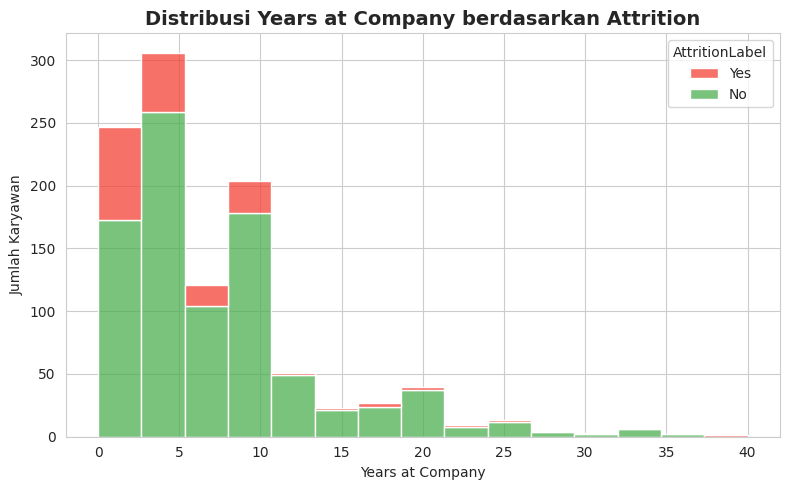

Insight: Karyawan yang baru bergabung (0-5 tahun) memiliki kecenderungan attrition yang lebih tinggi.


In [ ]:
#  YearsAtCompany vs Attrition
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='YearsAtCompany', hue='AttritionLabel',
             multiple='stack', palette={'No': '#4CAF50', 'Yes': '#F44336'}, bins=15)
plt.title('Distribusi Years at Company berdasarkan Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Years at Company')
plt.ylabel('Jumlah Karyawan')
plt.tight_layout()
plt.savefig('plot_years_attrition.png', dpi=150)
plt.show()

print('Insight: Karyawan yang baru bergabung (0-5 tahun) memiliki kecenderungan attrition yang lebih tinggi.')

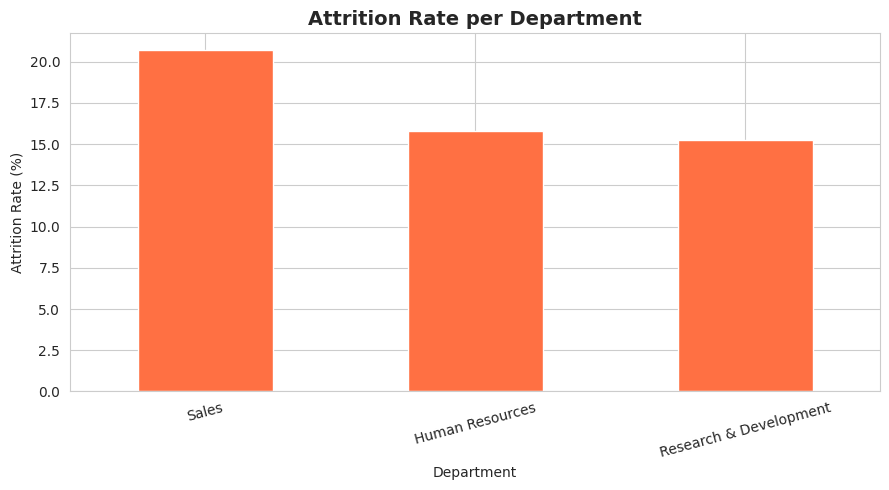

Insight: Sales memiliki attrition rate tertinggi dibandingkan department lainnya.


In [ ]:
# Attrition by Department
plt.figure(figsize=(9, 5))
dept_attr = df.groupby(['Department', 'AttritionLabel']).size().unstack(fill_value=0)
dept_attr_pct = dept_attr.div(dept_attr.sum(axis=1), axis=0) * 100
dept_attr_pct['Yes'].sort_values(ascending=False).plot(kind='bar', color='#FF7043', edgecolor='white')
plt.title('Attrition Rate per Department', fontsize=14, fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('plot_dept_attrition.png', dpi=150)
plt.show()

print('Insight: Sales memiliki attrition rate tertinggi dibandingkan department lainnya.')

## 5. Kesimpulan

Berdasarkan analisis EDA, faktor-faktor utama yang mempengaruhi attrition karyawan adalah:

| Faktor | Temuan |
|--------|--------|
| **OverTime** | Karyawan dengan overtime memiliki attrition rate lebih tinggi |
| **MonthlyIncome** | Karyawan dengan gaji rendah cenderung lebih sering resign |
| **JobSatisfaction** | Kepuasan kerja rendah berkorelasi dengan tingginya attrition |
| **YearsAtCompany** | Karyawan baru (< 5 tahun) paling rentan keluar |
| **Department** | Sales memiliki attrition rate tertinggi |

### Action Items

Beberapa rekomendasi yang dapat dilakukan perusahaan:

1. **Mengurangi beban overtime karyawan** — evaluasi distribusi kerja dan tambah tenaga jika diperlukan
2. **Meningkatkan kepuasan kerja** melalui program engagement, feedback berkala, dan pengembangan karier
3. **Meninjau kembali kompensasi** karyawan dengan gaji rendah, terutama di departemen Sales
4. **Program onboarding yang lebih kuat** untuk karyawan baru (0–5 tahun) agar meningkatkan retensi

In [ ]:
df.to_csv('employee_cleaned.csv', index=False)
print('File employee_cleaned.csv berhasil disimpan!')

File employee_cleaned.csv berhasil disimpan!


## Modeling

## Evaluation